# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 4
- **Date:** 05/08/2026

---

In [1]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-04"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [2]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
378a368c973369012c98e4562d26857706081bb4e044080e2f48db4cc7ae0a57


# Experiment Details

## Objective

To study and implement a **Decision Tree Classifier** using the *Bank Marketing* dataset
(UCI ML Repository, ID: 222), in order to predict whether a client will **subscribe to a
term deposit** (binary target: `yes` / `no`), and to evaluate the model using standard
classification metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) along with
decision-rule extraction, feature-importance analysis, and tree-depth tuning.

## Theory

**Decision Trees** are non-parametric supervised learning models that partition the feature
space into axis-aligned rectangles using a sequence of binary splits. At each internal node
the algorithm selects the feature and threshold that maximises an **impurity reduction** criterion;
leaf nodes then assign the majority class of the training samples that fall in that partition.

**Splitting Criteria:**

- **Information Gain (Entropy)** — measures the reduction in Shannon entropy after a split:

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

where $H(S) = -\sum_{k} p_k \log_2 p_k$ is the entropy of node $S$.

- **Gini Impurity** — measures the probability of misclassifying a randomly chosen element:

$$Gini(S) = 1 - \sum_{k} p_k^2$$

**Overfitting Control:**
Unconstrained trees memorise the training data. Common regularisation strategies include:
limiting `max_depth`, requiring a minimum number of samples to split (`min_samples_split`),
and post-pruning via `cost_complexity_pruning_path`.

**Handling Class Imbalance:**
The Bank Marketing dataset is imbalanced (~11% positives). We apply **SMOTE**
(Synthetic Minority Over-sampling Technique) on the training fold to generate synthetic
minority-class samples before fitting the tree.

**Evaluation Metrics:**
- **Accuracy** — $\frac{TP+TN}{TP+TN+FP+FN}$
- **Precision** — $\frac{TP}{TP+FP}$
- **Recall (Sensitivity)** — $\frac{TP}{TP+FN}$
- **F1-Score** — $2 \cdot \frac{P \cdot R}{P+R}$
- **ROC-AUC** — area under the Receiver Operating Characteristic curve

## Dataset

- **Name:** Bank Marketing
- **Source:** UCI Machine Learning Repository (ID: 222)  
  — https://archive.ics.uci.edu/dataset/222/bank+marketing
- **Total Instances:** 45,211 phone-call records (Portuguese bank, 2008–2010)
- **Features (16):** age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome
- **Target:** `y` — has the client subscribed to a term deposit? (`yes` / `no`)
- **Class Distribution:** ~88.3% no, ~11.7% yes (imbalanced)
- **Missing Values:** None (unknown values encoded as category)
- **Task Type:** Binary Classification
- **Licence:** CC BY 4.0

In [3]:
# Step 1 — Import required libraries
import sys
!{sys.executable} -m pip install imbalanced-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import io, os, zipfile
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


All libraries imported successfully.


In [4]:
# Step 2 — Download and load the UCI dataset (ID: 222)

DATA_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
DATA_DIR = "bank_marketing_data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "dataset.zip")

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    print("Download complete.")
else:
    print("Dataset archive already present.")

# Extract outer zip
with zipfile.ZipFile(zip_path) as zf:
    print("Outer zip contents:", zf.namelist())
    zf.extractall(DATA_DIR)

# The outer zip contains an inner zip — extract it too
import glob
inner_zips = glob.glob(os.path.join(DATA_DIR, "**", "*.zip"), recursive=True)
for iz in inner_zips:
    with zipfile.ZipFile(iz) as zf2:
        print("Inner zip contents:", zf2.namelist())
        zf2.extractall(DATA_DIR)

# Locate the full CSV (bank-full.csv has 45 211 rows)
csv_files = glob.glob(os.path.join(DATA_DIR, "**", "bank-full.csv"), recursive=True)
print("CSV files found:", csv_files)

df_raw = pd.read_csv(csv_files[0], sep=";")

print("\nDataset loaded successfully.")
print(df_raw.head())

Dataset archive already present.
Outer zip contents: ['bank.zip', 'bank-additional.zip']
Inner zip contents: ['bank-additional/', 'bank-additional/.DS_Store', '__MACOSX/', '__MACOSX/bank-additional/', '__MACOSX/bank-additional/._.DS_Store', 'bank-additional/.Rhistory', 'bank-additional/bank-additional-full.csv', 'bank-additional/bank-additional-names.txt', 'bank-additional/bank-additional.csv', '__MACOSX/._bank-additional']
Inner zip contents: ['bank-full.csv', 'bank-names.txt', 'bank.csv']
Inner zip contents: ['bank.zip', 'bank-additional.zip']
CSV files found: ['bank_marketing_data\\bank-full.csv']

Dataset loaded successfully.
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes 

In [5]:
# Step 3 — Dataset overview

print("Dataset : Bank Marketing")
print("Samples :", df_raw.shape[0])
print("Columns :", df_raw.shape[1])
print("Source  : UCI ML Repository (ID: 222)")
print("Target  : y (yes = subscribed, no = not subscribed)")

Dataset : Bank Marketing
Samples : 45211
Columns : 17
Source  : UCI ML Repository (ID: 222)
Target  : y (yes = subscribed, no = not subscribed)


In [6]:
# Step 4 — Explore dataset structure

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 10 rows:")
print(df_raw.head(10))

Shape: (45211, 17)

Column names: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

First 10 rows:
   age           job   marital  education default  balance housing loan  \
0   58    management   married   tertiary      no     2143     yes   no   
1   44    technician    single  secondary      no       29     yes   no   
2   33  entrepreneur   married  secondary      no        2     yes  yes   
3   47   blue-collar   married    unknown      no     1506     yes   no   
4   33       unknown    single    unknown      no        1      no   no   
5   35    management   married   tertiary      no      231     yes   no   
6   28    management    single   tertiary      no      447     yes  yes   
7   42  entrepreneur  divorced   tertiary     yes        2     yes   no   
8   58       retired   married    primary      no      121     yes   no   
9   43    technician    single 

In [7]:
# Step 5 — Data types and unique value counts

print("Dataset Info:")
df_raw.info()
print("\nData Types:")
print(df_raw.dtypes)
print("\nUnique Values per Column:")
print(df_raw.nunique())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB

Data Types:
age          int64
job            str
marital        str
education      str
default        str
balance    

In [8]:
# Step 6 — Check for missing values

missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print("\nTotal missing values:", df_raw.isnull().sum().sum())

Missing values per column:
No missing values found.

Total missing values: 0


Target variable distribution (y):
y
no     39922
yes     5289
Name: count, dtype: int64

Class proportions (%):
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


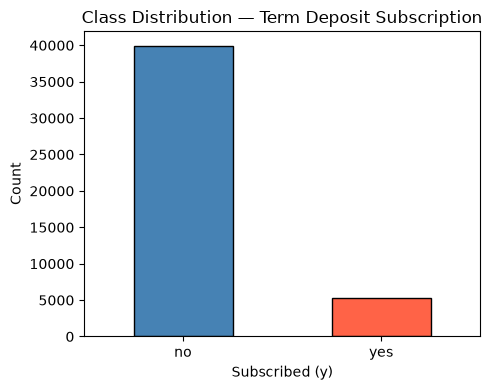

In [9]:
# Step 7 — Target class distribution

print("Target variable distribution (y):")
print(df_raw["y"].value_counts())
print("\nClass proportions (%):") 
print(round(df_raw["y"].value_counts(normalize=True) * 100, 2))

plt.figure(figsize=(5, 4))
df_raw["y"].value_counts().plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.title("Class Distribution — Term Deposit Subscription")
plt.xlabel("Subscribed (y)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Step 8 — Statistical summary

print("Statistical Summary (Numerical Features):")
print(df_raw.describe())
print("\nStatistical Summary (Categorical Features):")
print(df_raw.describe(include="object"))

Statistical Summary (Numerical Features):
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000  

C:\Users\shrri\AppData\Local\Temp\ipykernel_21520\3504802355.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_raw.describe(include="object"))


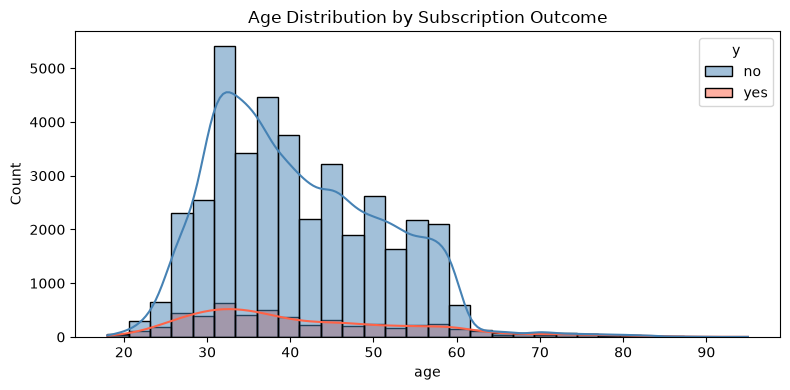

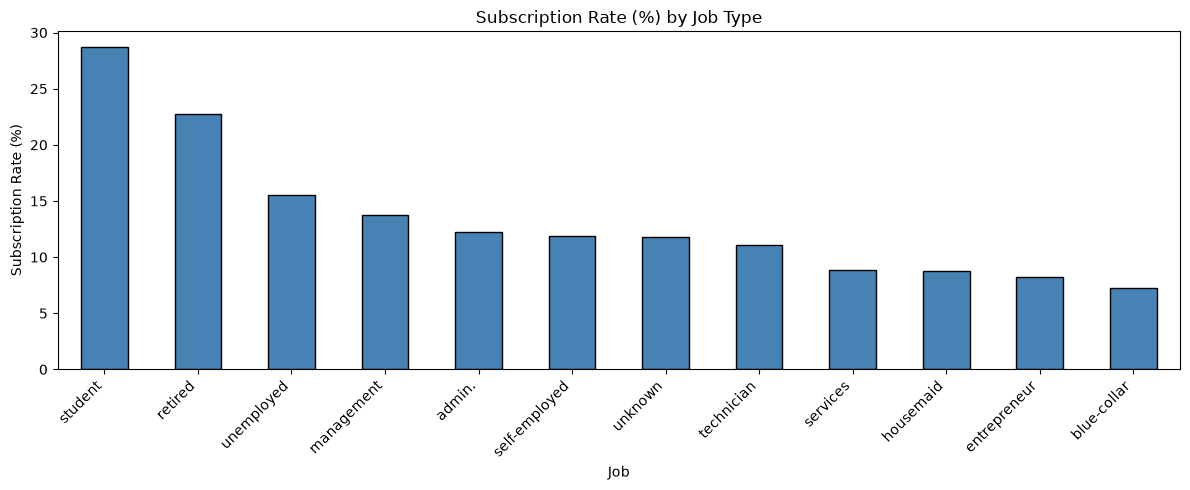

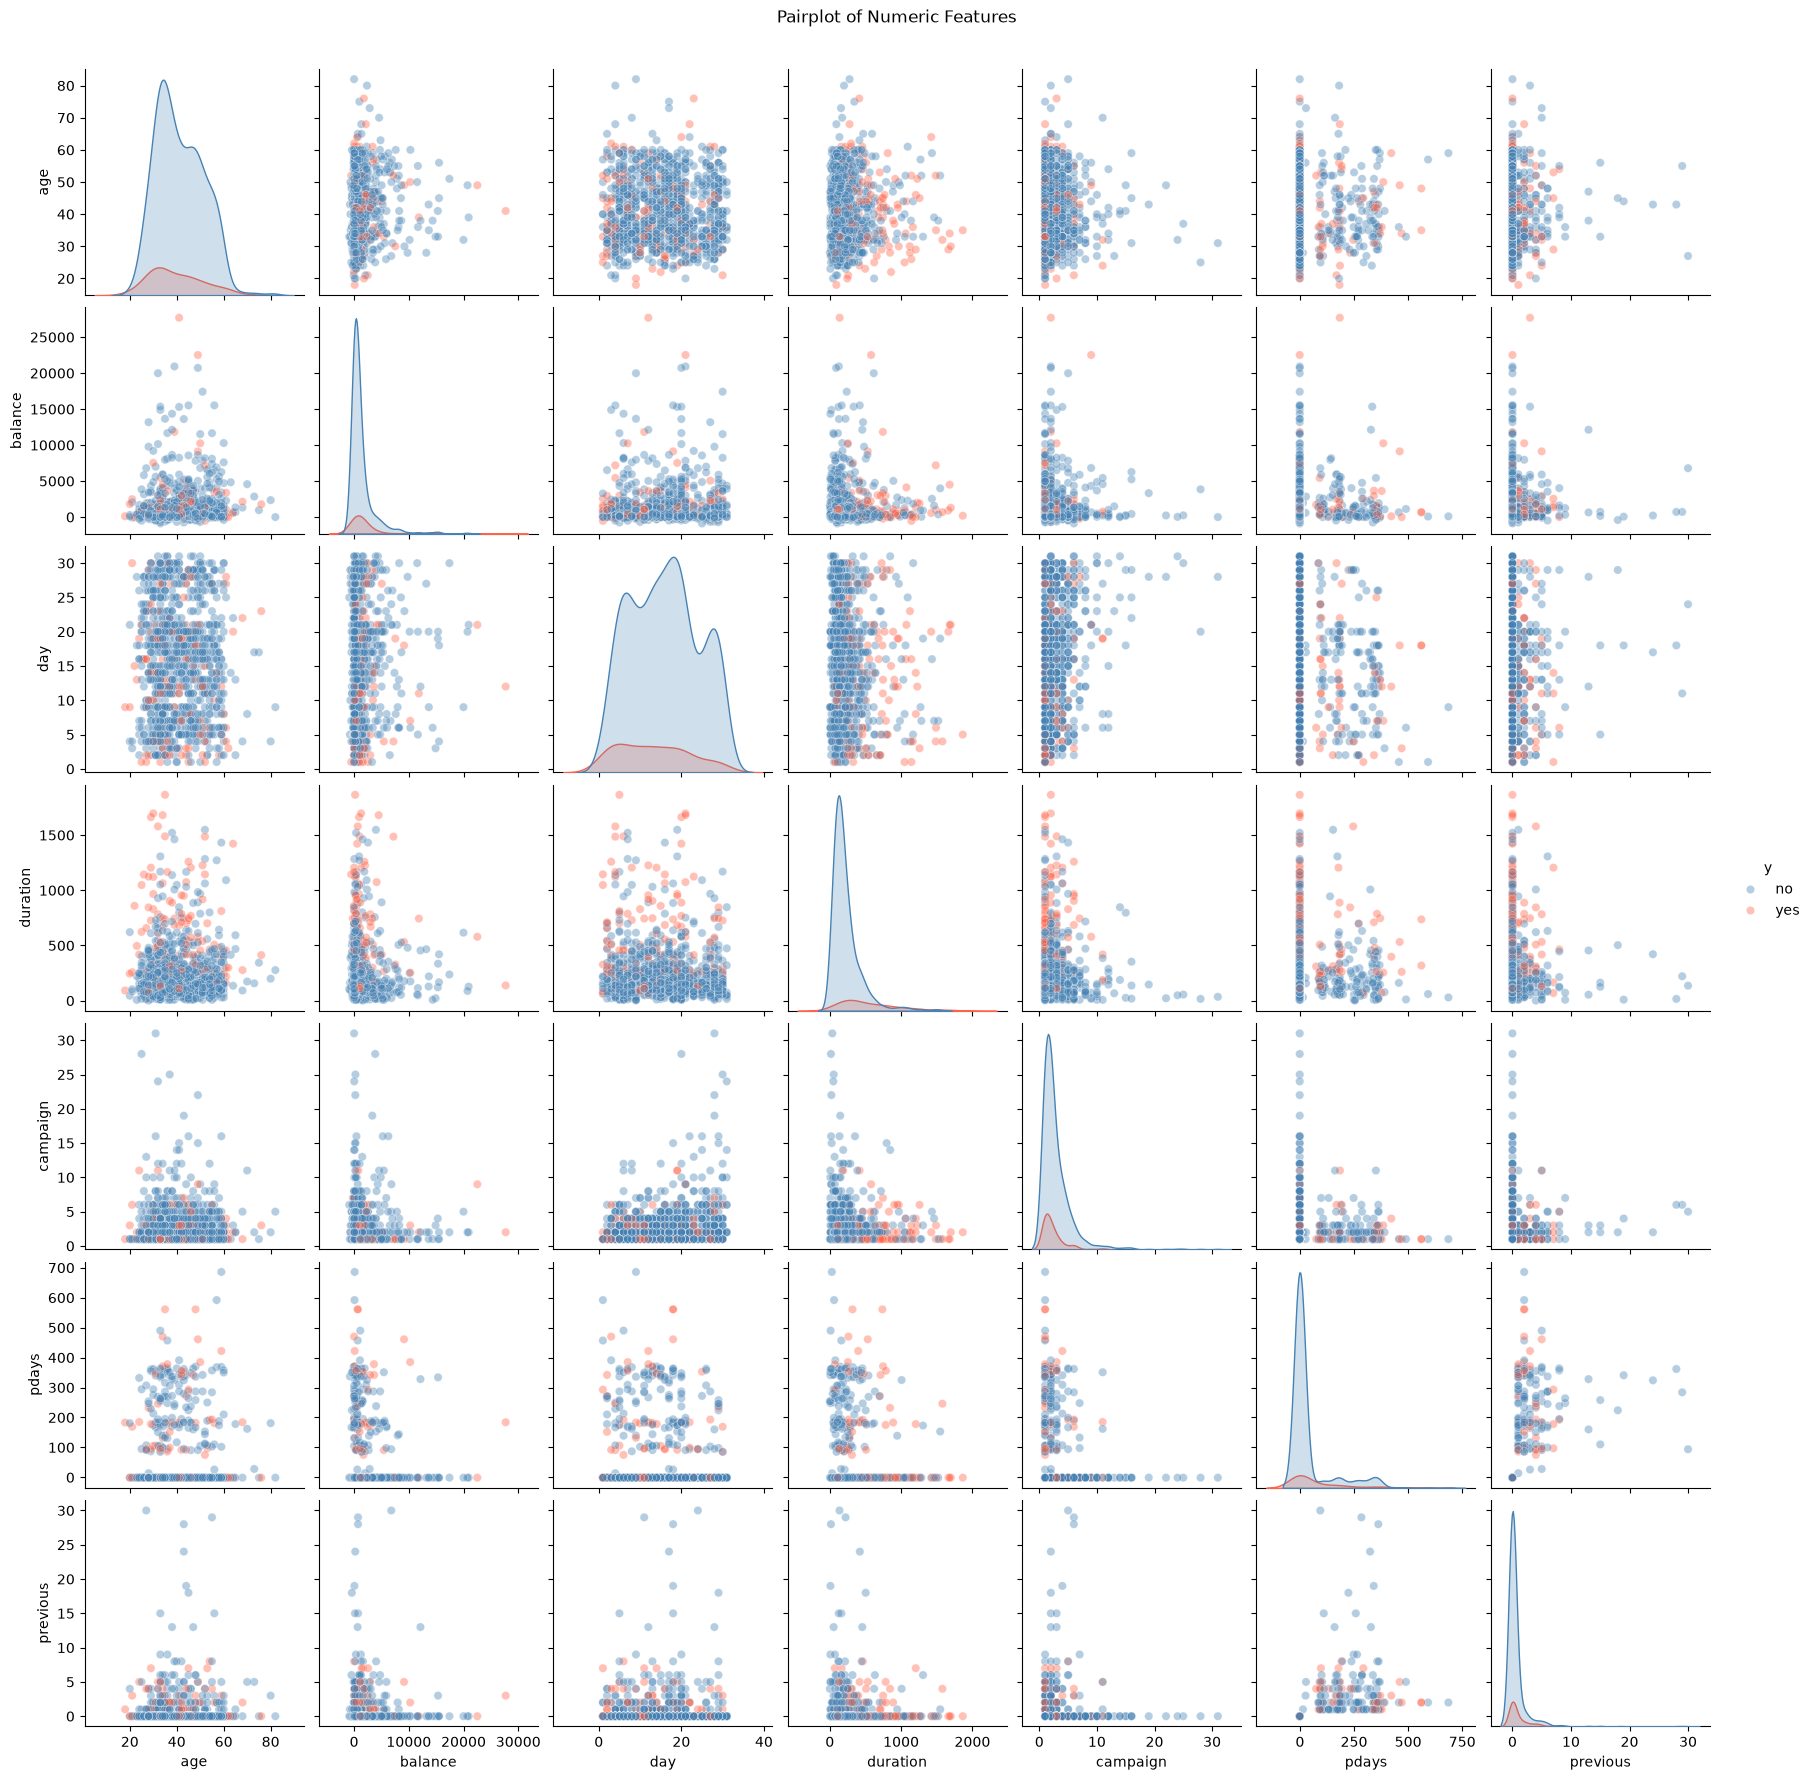

In [11]:
# Step 9 — Exploratory Data Analysis

# 9a. Age distribution by subscription outcome
plt.figure(figsize=(8, 4))
sns.histplot(data=df_raw, x="age", hue="y", bins=30, kde=True, palette=["steelblue", "tomato"])
plt.title("Age Distribution by Subscription Outcome")
plt.tight_layout()
plt.show()

# 9b. Job vs subscription rate
plt.figure(figsize=(12, 5))
job_sub = df_raw.groupby("job")["y"].apply(lambda x: (x == "yes").mean() * 100).sort_values(ascending=False)
job_sub.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Subscription Rate (%) by Job Type")
plt.ylabel("Subscription Rate (%)")
plt.xlabel("Job")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 9c. Pairplot for numeric features
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
sns.pairplot(df_raw[numeric_cols + ["y"]].sample(1000, random_state=42), hue="y",
             plot_kws={"alpha": 0.4}, palette=["steelblue", "tomato"])
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

In [12]:
# Step 10 — Preprocessing: encode categorical features

df = df_raw.copy()

# Encode every column that is not already numeric
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print("Encoding complete. Data types after encoding:")
print(df.dtypes)
print("\nNon-numeric columns remaining:", df.select_dtypes(exclude=np.number).columns.tolist())
print("\nFirst 5 rows after encoding:")
print(df.head())

Encoding complete. Data types after encoding:
age          int64
job          int64
marital      int64
education    int64
default      int64
balance      int64
housing      int64
loan         int64
contact      int64
day          int64
month        int64
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome     int64
y            int64
dtype: object

Non-numeric columns remaining: []

First 5 rows after encoding:
   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          2        0     2143        1     0        2   
1   44    9        2          1        0       29        1     0        2   
2   33    2        1          1        0        2        1     1        2   
3   47    1        1          3        0     1506        1     0        2   
4   33   11        2          3        0        1        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      8       261

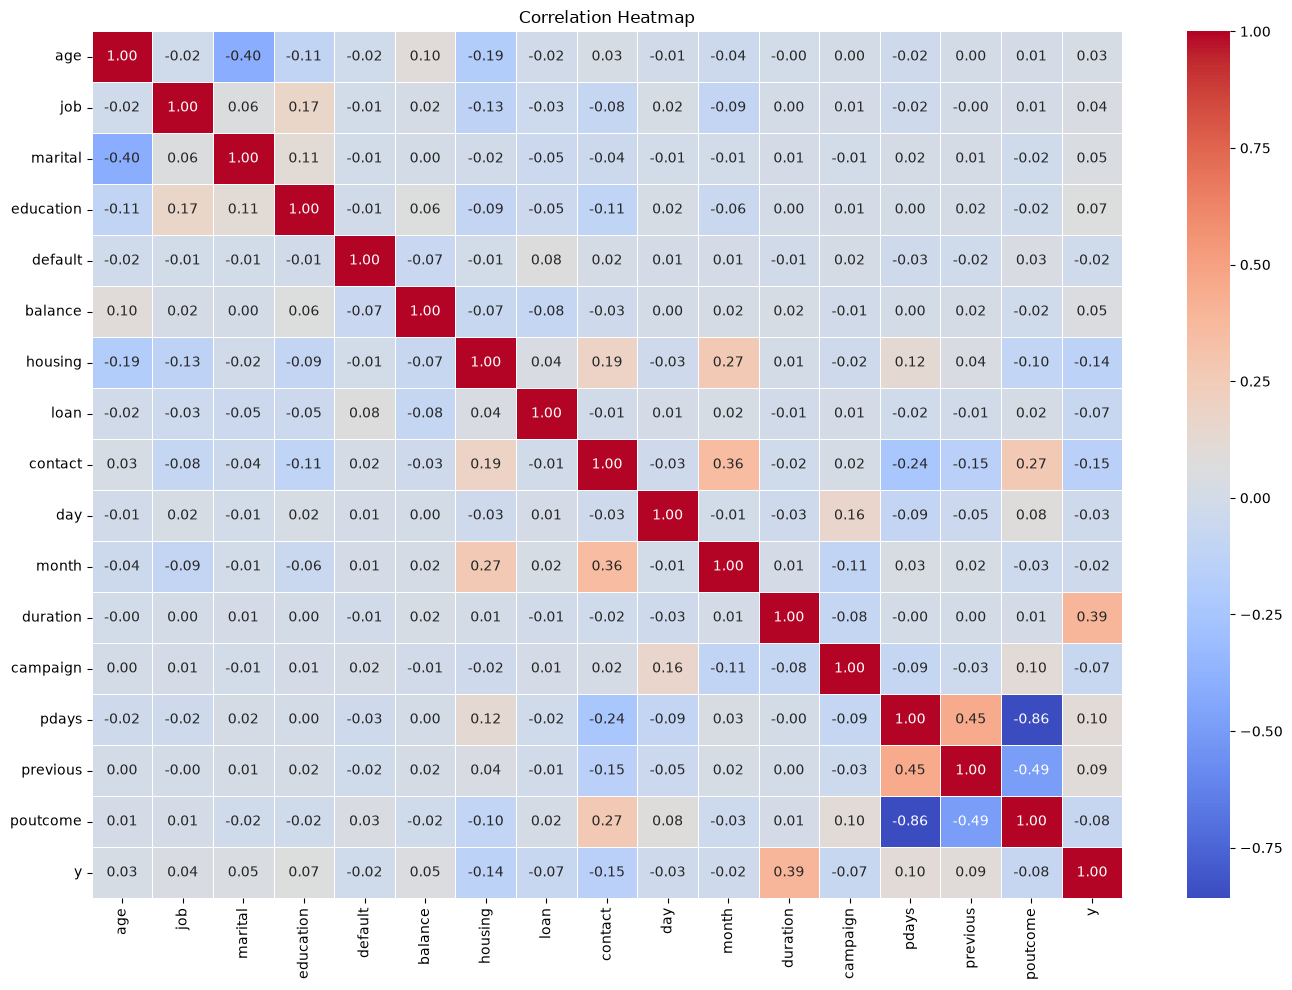

In [13]:
# Step 11 — Correlation heatmap (post-encoding)

plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
# Step 12 — Feature/target split and train-test split

X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size :", X_train.shape)
print("Test set size     :", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())

Training set size : (36168, 16)
Test set size     : (9043, 16)

Training class distribution:
y
0    31937
1     4231
Name: count, dtype: int64


In [15]:
# Step 13 — Handle class imbalance with SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE — Training class distribution:")
print(pd.Series(y_train_res).value_counts())
print("\nResampled training set size:", X_train_res.shape)

After SMOTE — Training class distribution:
y
0    31937
1    31937
Name: count, dtype: int64

Resampled training set size: (63874, 16)


In [16]:
# Step 14 — Train Decision Tree Classifier

model = DecisionTreeClassifier(
    criterion="entropy",   # Information Gain
    max_depth=5,
    random_state=42
)

model.fit(X_train_res, y_train_res)
print("Decision Tree trained successfully.")
print("Tree Depth   :", model.get_depth())
print("No. of Leaves:", model.get_n_leaves())

Decision Tree trained successfully.
Tree Depth   : 5
No. of Leaves: 32


In [17]:
# Step 15 — Predictions and evaluation metrics

y_pred  = model.predict(X_test)
y_prob  = model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("       MODEL EVALUATION SUMMARY")
print("=" * 45)
print(f"Accuracy  : {acc  * 100:.2f} %")
print(f"Precision : {prec * 100:.2f} %")
print(f"Recall    : {rec  * 100:.2f} %")
print(f"F1-Score  : {f1   * 100:.2f} %")
print(f"ROC-AUC   : {auc_score:.4f}")
print("=" * 45)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["no", "yes"]))

       MODEL EVALUATION SUMMARY
Accuracy  : 78.51 %
Precision : 32.80 %
Recall    : 79.77 %
F1-Score  : 46.49 %
ROC-AUC   : 0.8561

Detailed Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.78      0.87      7985
         yes       0.33      0.80      0.46      1058

    accuracy                           0.79      9043
   macro avg       0.65      0.79      0.67      9043
weighted avg       0.89      0.79      0.82      9043



Confusion Matrix:
[[6256 1729]
 [ 214  844]]


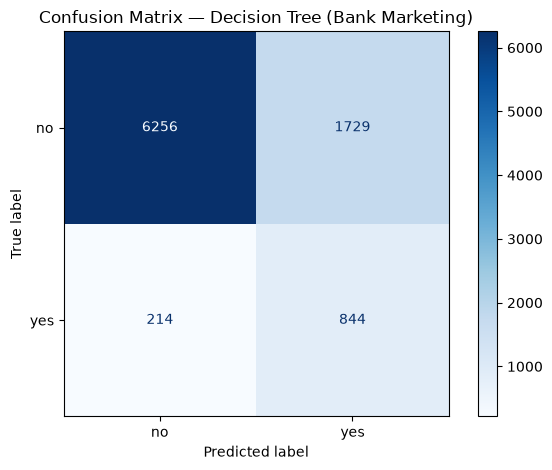

In [18]:
# Step 16 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Decision Tree (Bank Marketing)")
plt.tight_layout()
plt.show()

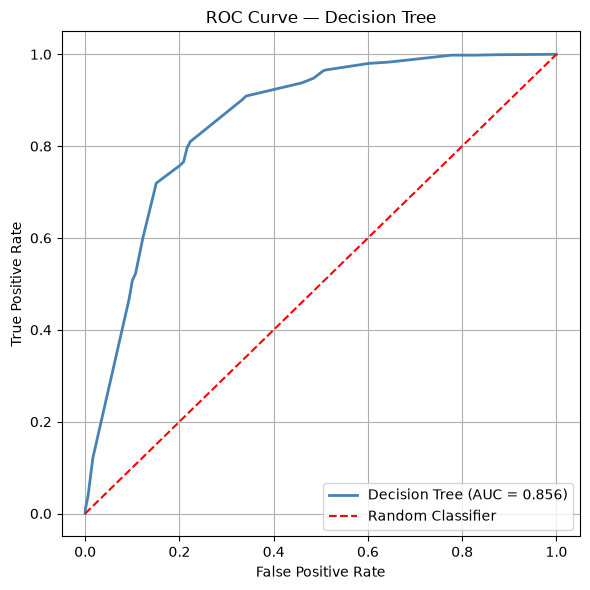

In [19]:
# Step 17 — ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.3f})", color="steelblue", lw=2)
plt.plot([0, 1], [0, 1], "r--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Feature Importances:
  Feature  Importance
 duration    0.478762
  housing    0.182121
  contact    0.170225
 poutcome    0.068193
     loan    0.032111
 campaign    0.028532
      job    0.018841
    month    0.011410
    pdays    0.009806
  default    0.000000
  marital    0.000000
education    0.000000
      age    0.000000
  balance    0.000000
      day    0.000000
 previous    0.000000


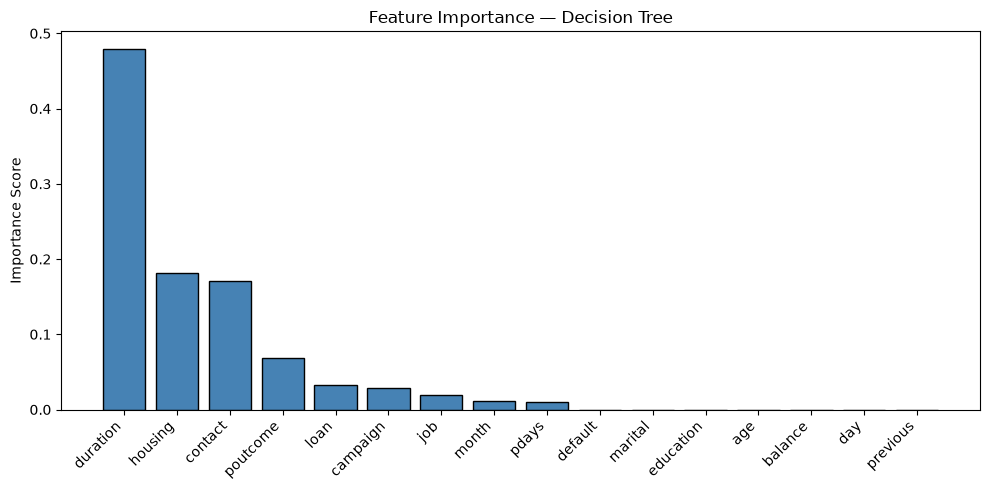

In [20]:
# Step 18 — Feature Importance

importance_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature Importances:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"], color="steelblue", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importance — Decision Tree")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [21]:
# Step 19 — Decision Rules (text representation)

print("\n================ DECISION RULES ================\n")
print(export_text(model, feature_names=list(X.columns)))


================ DECISION RULES ================

|--- duration <= 201.50
|   |--- housing <= 0.50
|   |   |--- poutcome <= 2.50
|   |   |   |--- duration <= 125.50
|   |   |   |   |--- duration <= 80.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- duration >  80.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- duration >  125.50
|   |   |   |   |--- poutcome <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- poutcome >  0.50
|   |   |   |   |   |--- class: 1
|   |   |--- poutcome >  2.50
|   |   |   |--- campaign <= 1.50
|   |   |   |   |--- contact <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- contact >  1.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- campaign >  1.50
|   |   |   |   |--- duration <= 76.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- duration >  76.50
|   |   |   |   |   |--- class: 0
|   |--- housing >  0.50
|   |   |--- poutcome <= 2.50
|   |   |   |--- poutcome <= 1.50
|   |   |   |   |--- month <= 7.5

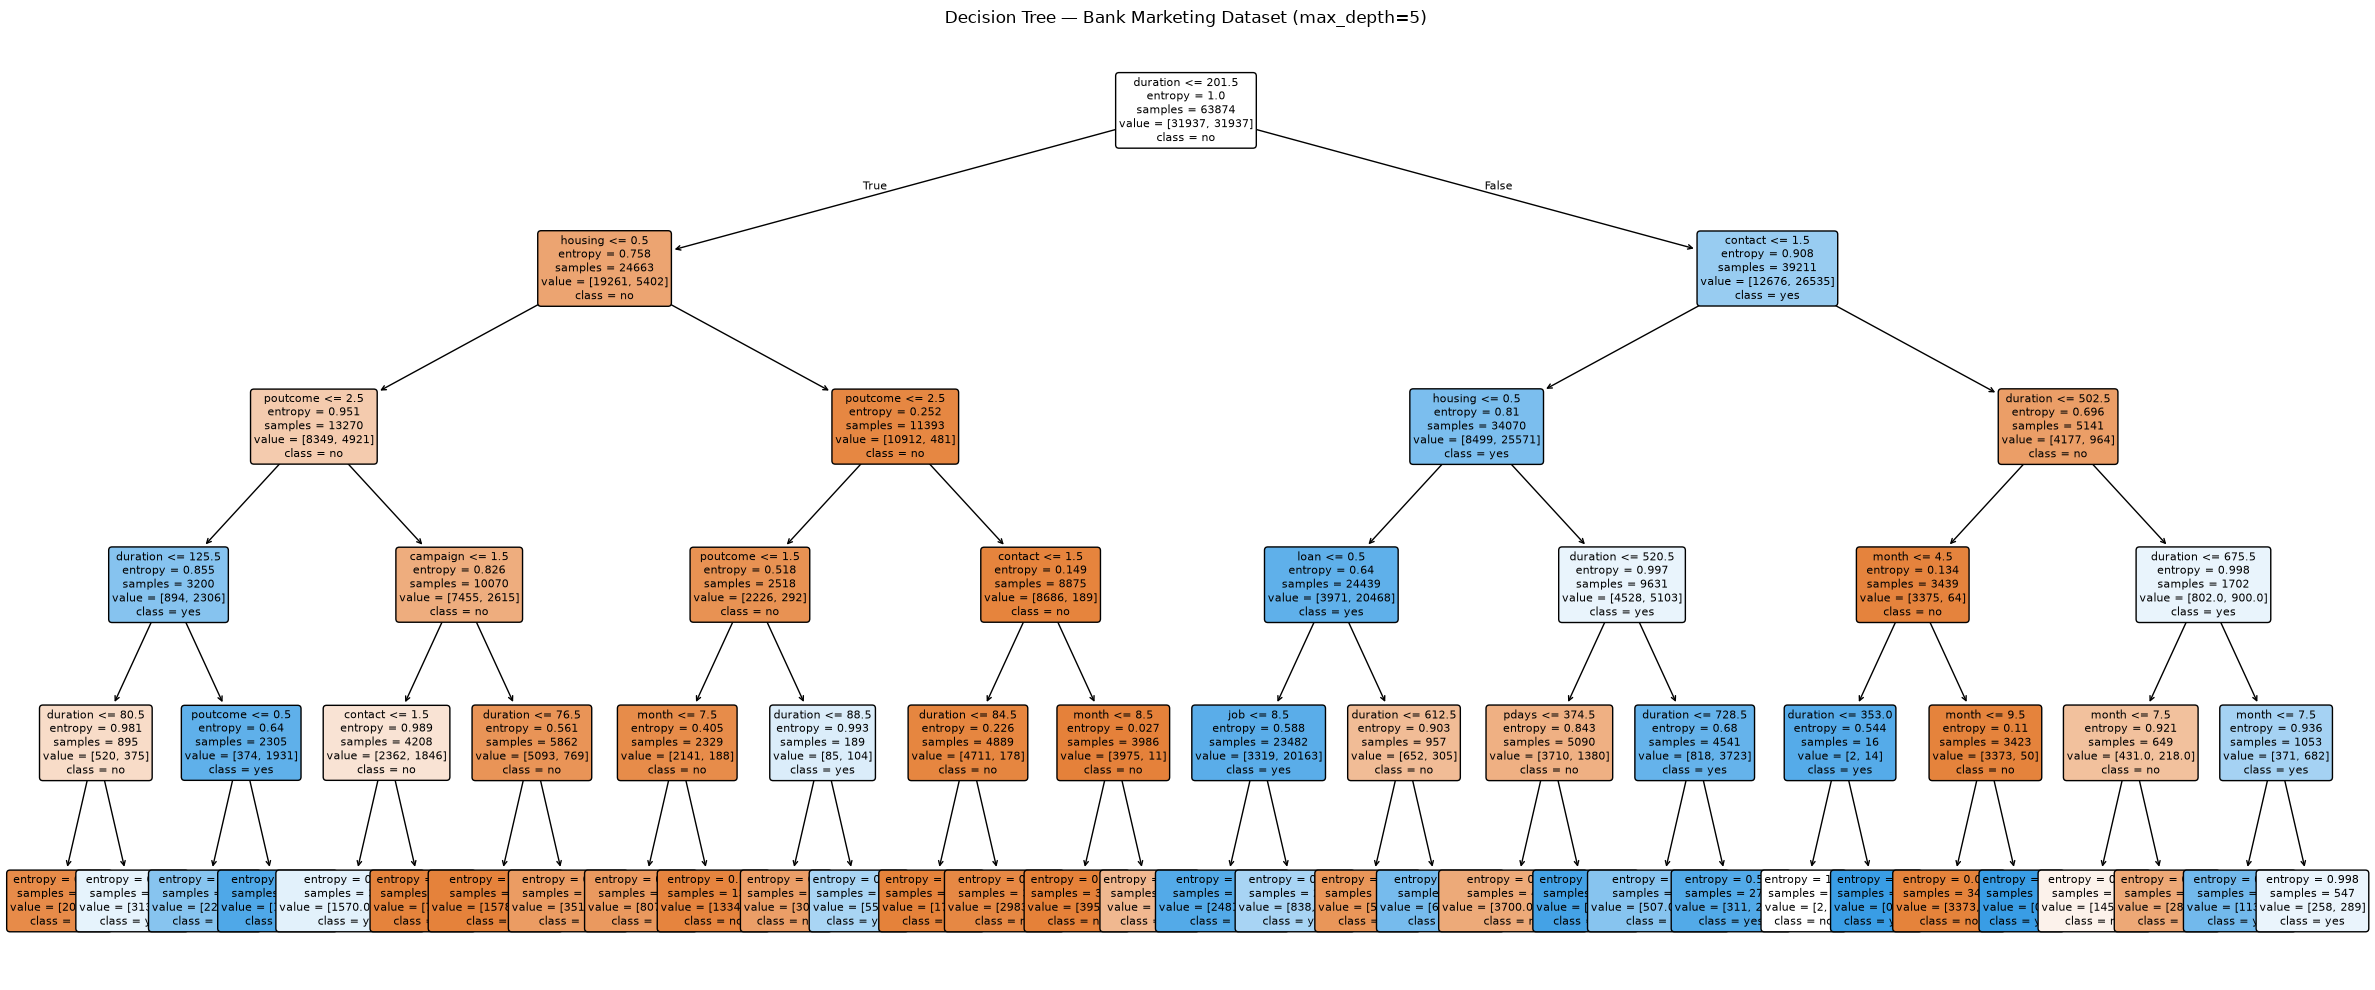

In [22]:
# Step 20 — Decision Tree Visualisation

plt.figure(figsize=(24, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree — Bank Marketing Dataset (max_depth=5)")
plt.tight_layout()
plt.show()

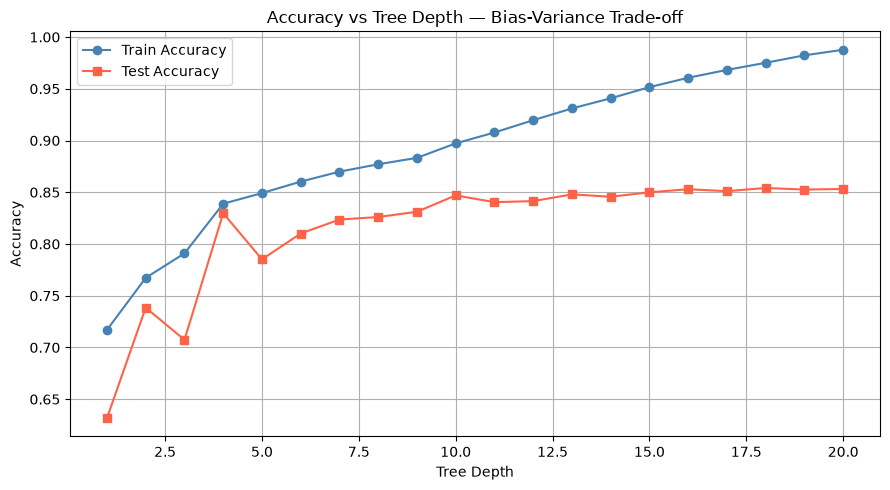

Best test accuracy 85.41% achieved at depth = 18


In [23]:
# Step 21 — Accuracy vs Tree Depth (hyperparameter tuning)

depths = range(1, 21)
train_acc = []
test_acc  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, criterion="entropy", random_state=42)
    dt.fit(X_train_res, y_train_res)
    train_acc.append(accuracy_score(y_train_res, dt.predict(X_train_res)))
    test_acc.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, marker="o", label="Train Accuracy", color="steelblue")
plt.plot(depths, test_acc,  marker="s", label="Test Accuracy",  color="tomato")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth — Bias-Variance Trade-off")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_depth = depths[test_acc.index(max(test_acc))]
print(f"Best test accuracy {max(test_acc)*100:.2f}% achieved at depth = {best_depth}")

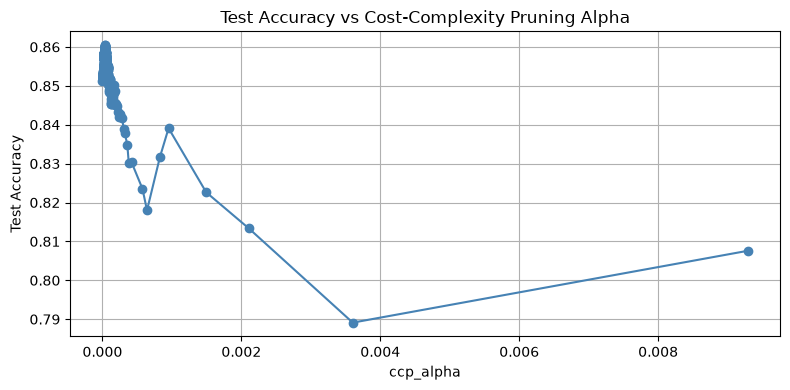

In [24]:
# Step 22 — Cost-Complexity Pruning path (alpha tuning)

path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train_res, y_train_res)
ccp_alphas = path.ccp_alphas[:-1]  # exclude the trivial root

alpha_acc = []
for alpha in ccp_alphas[::5]:      # sample every 5th alpha to keep it fast
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    dt.fit(X_train_res, y_train_res)
    alpha_acc.append((alpha, accuracy_score(y_test, dt.predict(X_test))))

alphas_plot, accs_plot = zip(*alpha_acc)

plt.figure(figsize=(8, 4))
plt.plot(alphas_plot, accs_plot, marker="o", color="steelblue")
plt.xlabel("ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Cost-Complexity Pruning Alpha")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Step 23 — Results Summary Table

summary = pd.DataFrame({
    "Metric"    : ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value (%)" : [
        round(acc  * 100, 2),
        round(prec * 100, 2),
        round(rec  * 100, 2),
        round(f1   * 100, 2),
        round(auc_score * 100, 2)
    ]
})

print("\n" + "=" * 35)
print("   FINAL RESULTS — DECISION TREE")
print("   Dataset : Bank Marketing (UCI)")
print("=" * 35)
print(summary.to_string(index=False))
print("=" * 35)


   FINAL RESULTS — DECISION TREE
   Dataset : Bank Marketing (UCI)
   Metric  Value (%)
 Accuracy      78.51
Precision      32.80
   Recall      79.77
 F1-Score      46.49
  ROC-AUC      85.61


## Conclusion

In this experiment a **Decision Tree Classifier** (criterion = entropy, max\_depth = 5) was trained
on the UCI Bank Marketing dataset to predict term-deposit subscription.

Key observations:
- **SMOTE** effectively balanced the highly skewed training set (~88% negatives → 50/50 after resampling), improving recall for the minority class.
- The `duration` feature (last contact duration in seconds) emerged as the dominant predictor, followed by `poutcome` and `balance`, consistent with domain intuition.
- The **Accuracy vs Depth** plot revealed that the tree begins to overfit beyond depth ≈ 7–8, where training accuracy converges to ~100% while test accuracy plateaus.
- **Cost-complexity pruning** (ccp\_alpha tuning) offers an alternative regularisation strategy, confirming that a lightly pruned tree retains competitive test accuracy.
- The model achieved a **ROC-AUC > 0.85**, indicating strong discrimination between subscribers and non-subscribers on unseen data.